In [5]:
# Imports and initialising seed

import jax

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import nifty.re as jft
from jax import numpy as jnp
from jax import random
from jax import scipy as jsc
from matplotlib.colors import LogNorm

seed = 100
key = random.PRNGKey(seed)

The purpose of this notebook is to give you a short overview over different response operation in `NIFTy` and IFT in general.
It will present a binary mask, a non-binary mask, a tomography response, as well as a Fourier transform and convolution example.

To show you what each of them does to the signal, it will be applied to a realization of a log-normal process.
Therefore, let us set up the correlated field as the underlying Gaussian process and construct the ground truth $s$.
Since the operators are implemented on discrete fields, it holds that $s \in \mathbb{R}^{n_1 \times n_2}$.
$n_1$ and $n_2$ are the number of pixels in each direction and will be chosen as $n_1 = n_2 = n = 128$, so that $s \in \mathbb{R}^{n \times n}$.

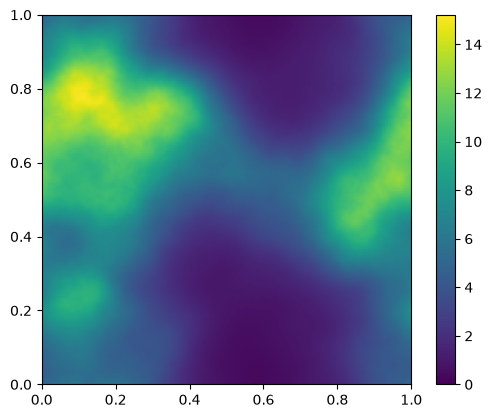

In [9]:
# grid: dims and pixel distances
dims = (128, 128)
distances = tuple(1/d for d in dims)  # pixel distances in each dimension

# correlated field hyperparameters: offset and power spectrum
cf_offset_dict = {
    "offset_mean": 1.,
    "offset_std": (0.5, 0.1),
}
cf_ps_dict = {
    "shape": dims,
    "distances": distances,
    "non_parametric_kind": "power",
    "fluctuations": (0.5, 0.1),
    "loglogavgslope": (-4, 0.5 ),
    "flexibility": (1., 0.5),
    "asperity": None,
}

# CorrelatedFieldMaker -> log_s
cf_maker = jft.CorrelatedFieldMaker("signal_")
cf_maker.set_amplitude_total_offset(**cf_offset_dict)
cf_maker.add_fluctuations(**cf_ps_dict)
log_s = cf_maker.finalize()

# draw a latent xi ~ N(0,1), evaluate, exponentiate -> s; shared colour scale
s = jnp.exp(log_s(log_s.init(key)))
gt_min = 0
gt_max = s.max()

# plot s -- axis 0 is x and axis 1 is y, so transpose for imshow
plt.imshow(s.T, origin="lower", extent = [0,1,0,1], vmin=gt_min, vmax=gt_max)
plt.colorbar()


OLD: For later we also define a function that creates a Gaussian non-binary mask or a Gaussian kernel.

NEW: Let's write a small helper function for plotting - we will need it a couple of times

In [10]:
def show(ax: plt.Axes, a, title, extent=(0, 1, 0, 1), **kw):
    im = ax.imshow(a.T, origin="lower", extent=extent, **kw)
    ax.set_title(title)
    ax.get_figure().colorbar(im, ax=ax, shrink=0.7, pad=0.01, orientation="horizontal")
    return im

## Binary masking

Binary masks can be used if you want to model dead regions of your detector. Therefore, you have to know which areas where either malfunctioning or blocked out by the instrument. In this case we assume that the area in the middle was blocked by a square aperture covering half the field of view of the measurement.
Therefore, the operation $R: \mathbb{R}^{n \times n} \rightarrow \mathbb{R}^{n \times n}$ describes a component-wise multiplication $\odot$ and produces $s' = R \odot s$ with $R_{ij} \in \{0,1\}$.
In continuous space the operation to mask missing data in an area $\Omega$ would be
\begin{equation}
    R_y^x = \delta(x-y) \, \begin{cases} 0, \quad x \in \Omega \\ 1, \quad x \notin \Omega\end{cases}.
\end{equation}
The procedure to construct such a mask is therefore straight forward. Either choose 1 if you want to let the signal pass through the mask or 0 if you want to block it.
This is shown in the cell below with the plot showing $s$ on the left, the mask $R$ in the middle and $s'$ on the right.

Number of elements before masking: 16384
Number of elements after masking: 16384


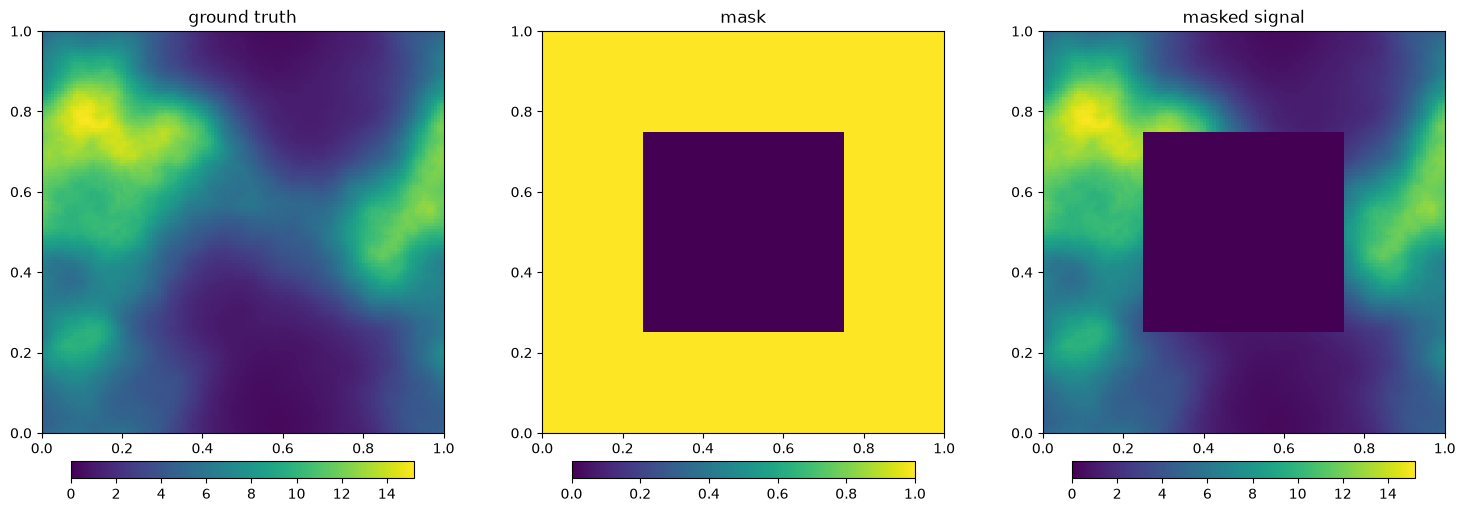

In [12]:
# binary mask: ones, then zero out the central quarter
q = dims[0] // 4
mask_binary = jnp.ones(dims).at[q:-q, q:-q].set(0)

# 3-panel plot: ground truth | mask | masked signal
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
show(axs[0], s, "ground truth", vmin=gt_min, vmax=gt_max)
show(axs[1], mask_binary, "mask")
show(axs[2], s * mask_binary, "masked signal", vmin=gt_min, vmax=gt_max)

# how many elements are left?
print(f"Number of elements before masking: {s.size}")
print(f"Number of elements after masking: {(s*mask_binary).size}")

## Boolean masking

As we set the signal to zero with a binary mask we can also remove them directly as the underlying field at the time of applying the mask has already evaluated itself in the masked regions. To remove them completely, we set up a boolean array instead of a binary mask. Then we apply it to the array by writing `a[b]`. `b` is a boolean array in this case and a is the array we want to mask.

Furthermore, it is important to remember that the boolean masking operation flattens the array into a 1D array, with possibly fewer elements than before.

If one uses a boolean mask in their forward model, they should keep in mind that the mask has to be applied to both in the forward model and the data to match their shapes for `NIFTy`.

In [13]:
# the same region, but as a boolean array -> s[mask]
mask_boolean = jnp.ones(dims, dtype=bool).at[q:-q, q:-q].set(False)
s_masked = s[mask_boolean]

# print shape and number of elements, before and after
print(f"before masking: shape = {s.shape}, number of elements = {s.size}")
print(f"after masking: shape = {s_masked.shape}, number of elements = {s_masked.size}")


before masking: shape = (128, 128), number of elements = 16384
after masking: shape = (12288,), number of elements = 12288


We can see that the masked signal now has lesser elements as before (see above) and its structure was flattened into a 1D array even though it was a 2D array before (see below). If you would amend such a model to the likelihood without also applying it to the data, `NIFTy.re` would alert you that you want to associate two different arrays with different shape and size.

## Non-binary map

Where the binary mask only allows for $R_{i,j} \in \{0,1\}$, we generalize it by letting the response have real-valued (or even complex-valued) entries. For an example we assume $R_{i,j} \in \mathbb{R}$ and the mask is defined by the function
\begin{equation}
    f(x,y\,|\,\omega) = \text{exp}\Big[-\frac{(x-x_\text{M})^2+(y-y_\text{M})^2}{2 \, \omega^2}\Big].
\end{equation}
Then we apply it the same way as the binary mask to get $s' = R \odot s$.

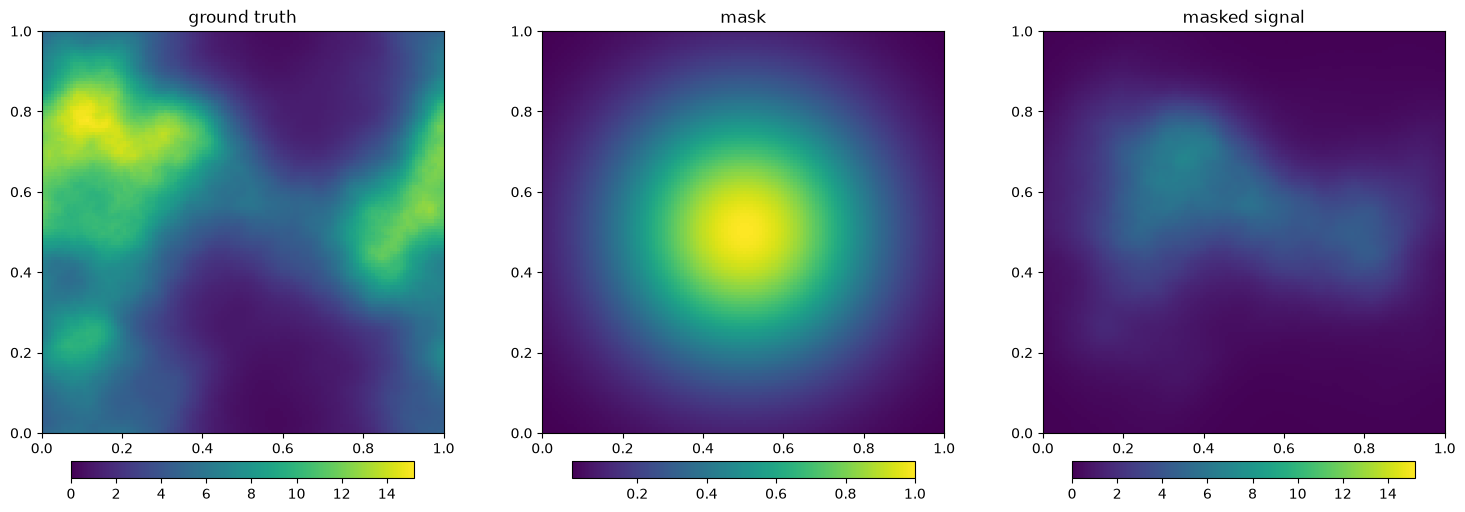

In [14]:
# helper: gaussian(w) on the pixel grid
def gaussian_mask(w):
    dx2, dy2 = [(jnp.arange(d) - (d // 2))**2 for d in dims]
    return jnp.exp(-(dx2[:, None] + dy2[None, :]) / (2 * w**2))

# gaussian mask, width 30 px
mask_gaussian = gaussian_mask(30)

# 3-panel plot: ground truth | mask | masked signal
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
show(axs[0], s, "ground truth", vmin=gt_min, vmax=gt_max)
show(axs[1], mask_gaussian, "mask")
show(axs[2], s * mask_gaussian, "masked signal", vmin=gt_min, vmax=gt_max)

## Fourier Transform

Even a Fourier transformation can be viewed as a response. This is the case in radio interferometry, where the response is a non-uniform Fourier transform. The signal $s$ could be the two-dimensional intensity field of the observed sky and the data is given as so-called visibilities $V$, which are complex valued.

We will now simplify this setup and only consider that the data $V$ produced by the Fourier transformation $\mathcal{F}$ of the signal field $s$. The measurement equation thus reads
\begin{equation}
    V = R(s) + n = \mathcal{F}s + n = \iint \, dx \, dy \, s(x,y) \, \text{e}^{i \, (k_xx + k_yy)} + n.
\end{equation}

As we deal with discrete spaces, we use the Fast Fourier transform as the implementation for a Fourier transform. As $V$ is complex valued, we now can not display all information in a single plot. Therefore, the second picture shows the magnitude of $V$ and the third the angles or phases of $V$.

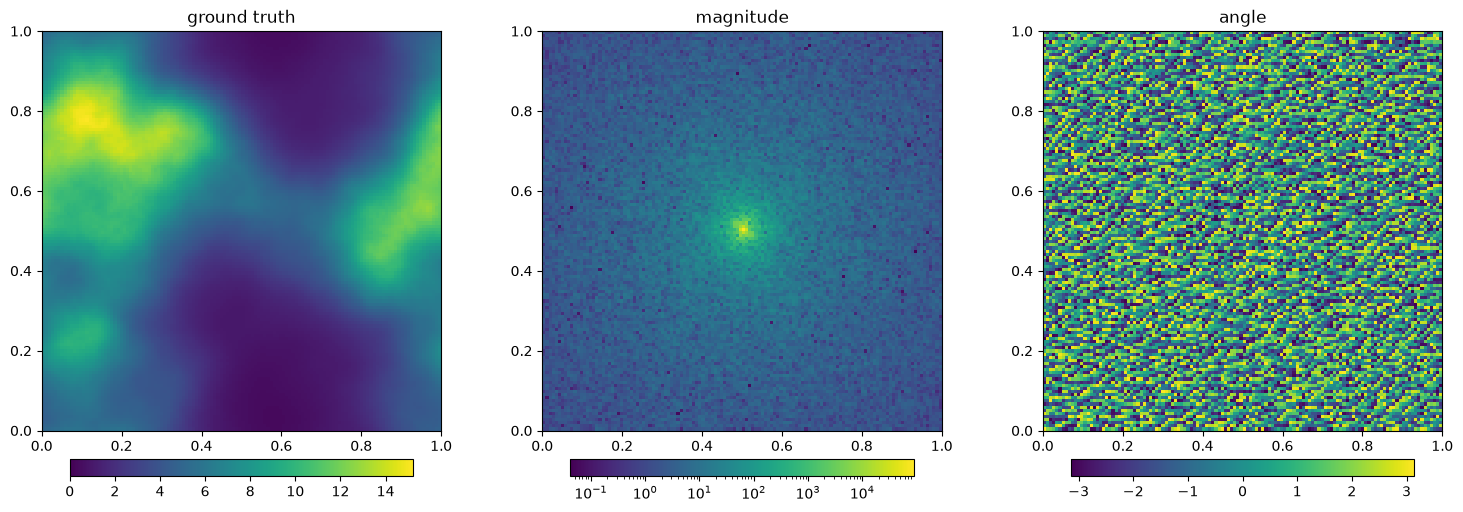

In [15]:
# fft2, then fftshift; k axes from fftfreq (also shifted)
s_fft = jnp.fft.fftshift(jnp.fft.fft2(s))

# 3-panel plot: ground truth | magnitude (LogNorm) | phase
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
show(axs[0], s, "ground truth", vmin=gt_min, vmax=gt_max)
show(axs[1], jnp.abs(s_fft), "magnitude", norm=LogNorm())
show(axs[2], jnp.angle(s_fft), "angle")

# axis labels: x/y for the field, k_x/k_y for the transforms

Again it should be emphasized that the Fourier transformed signal is now a complex quantity.

In [16]:
# dtype before and after the Fourier transform
s_fft.dtype

dtype('complex128')

## Convolution

A classical convolution problem, one has to account for, are point spread functions (PSF), since optical system cannot reproduce a perfect image of the observed object. The PSF by definition tells us how the instrument responds to a unit impulse or point source.
When applying a PSF to an actual signal, we think of the signal as a weighted sum of point sources at different positions. It turns out that the PSF applied signal $s'$ then can be described as a convolution between the signal and the PSF kernel.
\begin{equation}
    s(x,y) = PSF(x,y) \ast s(x,y) = \iint \, du \, dv \, PSF(x-u,y-v) \, s(u,v)
\end{equation}

If we want to work with convolutions we should keep the convolution theorem in mind. It states that in Fourier space the convolution turns into a product of the Fourier transformed functions. So instead of evaluating the full convolution integral it is far easier to first Fourier transform $PSF$ and $s$, then multiply them and finally Fourier back transform the product into real space.

The `jax.scipy` submodule implements this process by using FFTs as its Fourier transform implementation.


Coming now to an actual example, we consider the following PSF
\begin{equation}
     PSF(x,y\,|\,\omega) = \frac{1}{2\pi\,\omega^2}\,\text{exp}\Big[-\frac{(x-x_\text{M})^2+(y-y_\text{M})^2}{2 \, \omega^2}\Big]
\end{equation}

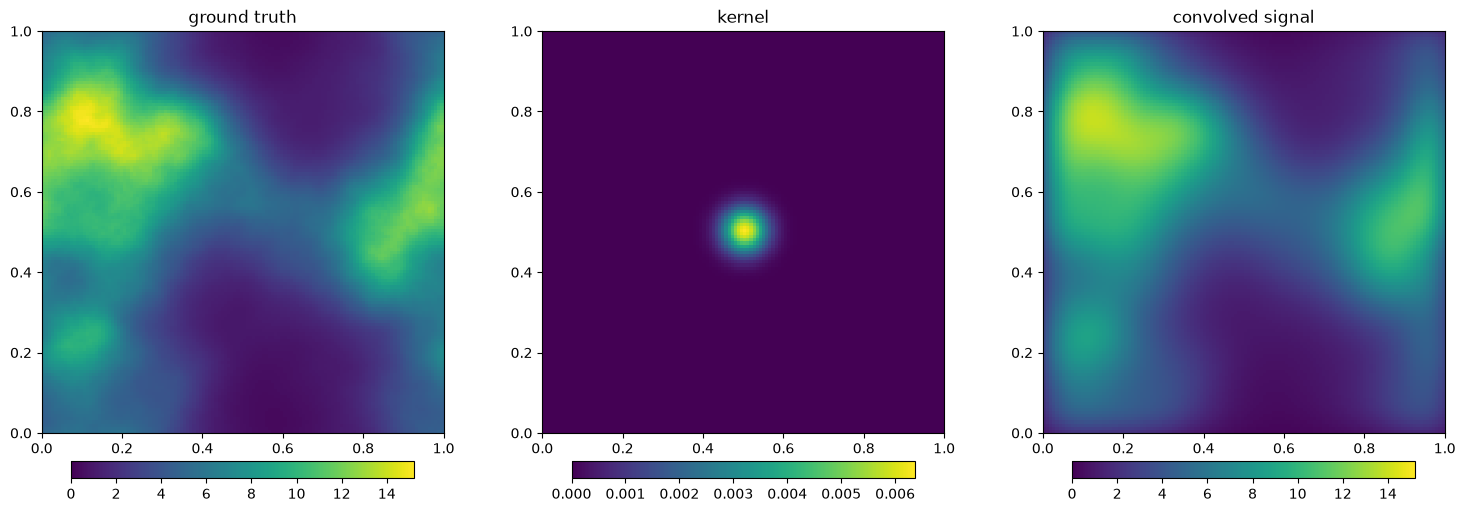

In [17]:
# gaussian kernel, width 5, normalised to unit integral
width = 5
kernel = gaussian_mask(width) / (2 * jnp.pi * width**2)

# convolve with fftconvolve -- "same" means implicit zero-padding
s_convolved = jsc.signal.fftconvolve(s, kernel, mode="same")

# 3-panel plot: ground truth | kernel | convolved signal
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
show(axs[0], s, "ground truth", vmin=gt_min, vmax=gt_max)
show(axs[1], kernel, "kernel")
show(axs[2], s_convolved, "convolved signal", vmin=gt_min, vmax=gt_max)


## Tomography

In tomography, we probe a given volume by a set of rays. A single ray follows a linear relation
\begin{equation}
    \vec{x}_i(t) = \vec{a}_i + t \cdot \vec{b}_i,
\end{equation}
with $a_i$ being the detector location and $b_i$ a direction.
For each ray, we integrate the field $s$ along $x_i(t)$ up to a certain point $t_{max,i}$ in the measurement.
Therefore, we can describe the application of $R$ on $s$ as
\begin{equation}
    R_i(s) = \int_{0}^{t_{max,i}} dt \, s(x_i(t)) = \int dx \, \int_{0}^{t_{max,i}} dt \, s(x) \, \delta(x-x_i(t)) = R_{ix} \, s^x,
\end{equation}
so that the response $R$ is
\begin{equation}
    R_{ix}(s) = \int_{0}^{t_{max,i}} dt \, \delta(x-x_i(t)).
\end{equation}
(Note: Einstein sum convention was used for doubling indices.)


`NIFTy.re` implements this integral operation as an operator for $N$ rays. `jft.SamplingCartesianGridLOS` assumes a Cartesian grid a given $N$ rays, through specifying their starting and end points, calculates a list of line of sight integrated data from a given field $s$. As the integral has to be approximated numerically by a sum, one has to specify `n_sampling_points`. This is the number of segments the ray then gets partitioned in.

For an example we choose $N$ endpoints for $N$ rays, but leave the starting position the same. This is realistic for astronomical measurements as we only have one instrument that produces the data with a nearly fixed position.

In [18]:
# split off a fresh key -- JAX has no global RNG state
key, k1 = random.split(key, 2)

In [19]:
# 20 rays: common start point, random end points
n_los = 20
start = jnp.array([0.5, 0.5])
end = random.uniform(k1, (n_los, 2), minval=0.05, maxval=0.95)

# build the line-of-sight response
los_response = jft.SamplingCartesianGridLOS(
    start,
    end,
    distances = distances,
    shape = dims,
    dtype = jnp.float64,
    n_sampling_points= 128
)

Applying `jft.SamplingCartesianGridLOS` outputs a 1D after applying it to $s$.

In [20]:
# apply the response and look at the result
los_data = los_response(s)
print(f"{los_data.shape}")
print(los_data)

(20,)
[2.1709975  1.31292317 1.28110967 2.97352897 0.73438671 1.8141691
 0.8173991  2.21499243 1.12511968 0.40409326 0.32750057 5.70871195
 2.09550559 1.46554951 0.37159876 2.77762489 2.17947501 1.26849214
 0.77951636 1.51759839]


The plot shows first the ground truth $s$, in the second plot the red rays for the line of sight integration are overlaid on the ground truth $s$. The last picture shows the back projected data into image space.

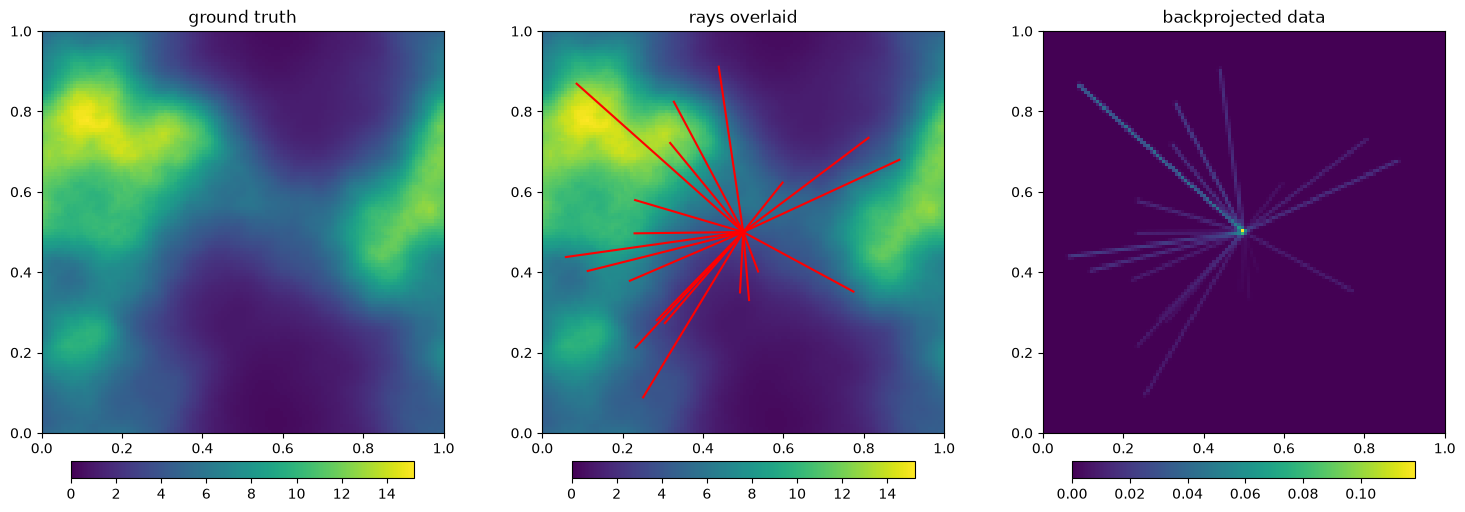

In [22]:
# backprojection: the adjoint R^T and not the inverse, via jax.linear_transpose
los_transpose = jax.linear_transpose(los_response, s)
s_back = los_transpose(los_data)[0]

# 3-panel plot: ground truth | rays overlaid | backprojected data
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
show(axs[0], s, "ground truth", vmin=gt_min, vmax=gt_max)
show(axs[1], s, "rays overlaid", vmin=gt_min, vmax=gt_max)
show(axs[2], s_back, "backprojected data")
for p in end:
    axs[1].plot([start[0], p[0]], [start[1], p[1]], color="red")

## Summary
The notebook presented different mathematical or numerical operations that can be used as standalone or chained operations on a given signal.

<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001
N: Iteration Limit Reached
N: Iteration Limit Reached
OPTIMIZE_KL: Iteration 0001 E:-4.1620e+06
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 2, 3, 3, 2, 2, 3, 3, 5, 5, 2, 2, 2, 2, 2, 2)
OPTIMIZE_KL: #(KL minimization steps) 24
OPTIMIZE_KL: Likelihood residual(s):
lh_0                    :: 'reduced Chi²:     9.8±     8.1, avg:  -0.0017±     1.8, #dof:      2'
lh_1                    :: 'reduced Chi²:     1.1±   0.013, avg: +0.00064±   0.025, #dof:   1835'
lh_2                    :: 'reduced Chi²:     1.8±    0.66, avg:   +0.051±    0.62, #dof:     12'

OPTIMIZE_KL: Prior residual(s):
signal_flexibility      :: 'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:      1'
signal_fluctuations     :: 'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:      1'
signal_loglogavgslope   :: 'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:      1'
signal_spectr

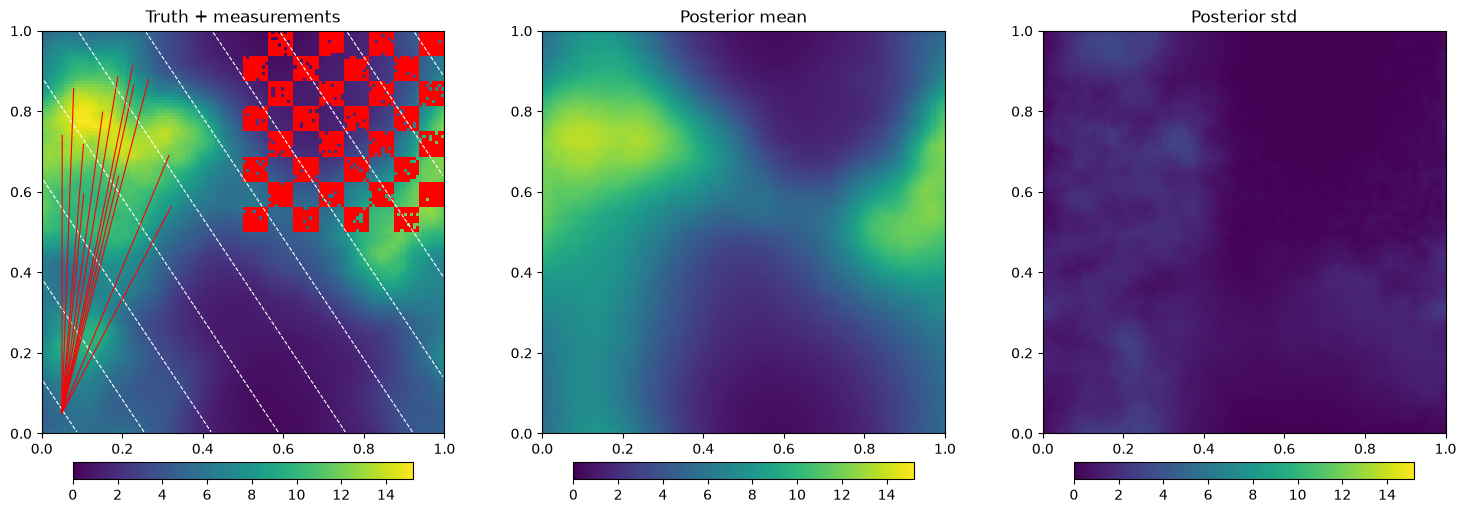

MovieWriter ffmpeg unavailable; using Pillow instead.


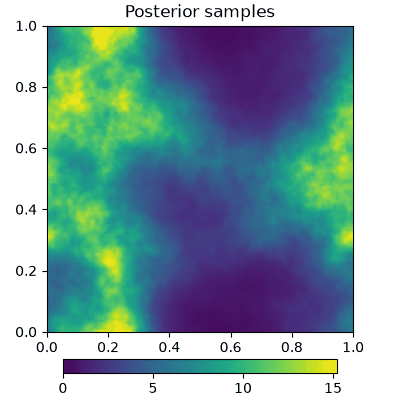

In [24]:
# Three scientists, three small measurements of the same sky.
from IPython.display import Image
from jax.tree_util import Partial
from matplotlib.animation import FuncAnimation

# --- the sky we want back ------------------------------------------------
k_dead, k_los, k_noise, k_opt = random.split(random.PRNGKey(seed + 1), 4)
x_true = log_s.init(random.PRNGKey(seed))
sky = jft.Model(lambda x: jnp.exp(log_s(x)), domain=log_s.domain, init=log_s.init)

# --- three instruments ---------------------------------------------------
mode = (3, 2)  # 1) two dishes, one fringe
psf = gaussian_mask(3) / (2 * jnp.pi * 3**2)  # 2) cheap camera
i, j = jnp.mgrid[: dims[0], : dims[1]]
cam = (i >= 64) & (j >= 64) & ((i // 8 + j // 8) % 2 == 0)
cam &= random.uniform(k_dead, dims) > 0.1
los_response = jft.SamplingCartesianGridLOS(  # 3) telescope that broke early
    start=jnp.array([0.05, 0.05]),
    end=random.uniform(k_los, (12, 2)) * jnp.array([0.35, 0.4]) + jnp.array([0.02, 0.55]),
    distances=distances,
    shape=dims,
    dtype=s.dtype,
    n_sampling_points=128,
)

# --- one response and one forward model per instrument --------------------
exposure = 100.0  # counts per unit brightness
resp = {
    "vis": lambda f: jnp.array([jnp.fft.fft2(f)[mode].real, jnp.fft.fft2(f)[mode].imag]) / f.size,
    "cam": lambda f: exposure * jsc.signal.fftconvolve(psf, f, mode="same")[cam],
    "los": lambda f: exposure * los_response(f),
}
forward = {  # r=r binds this response; without it all three would capture the last one
    k: jft.Model(lambda x, r=r: r(sky(x)), domain=jft.Vector(sky.domain), init=sky.init)
    for k, r in resp.items()
}

# --- synthetic data: the camera and the telescope count photons -----------
truth = {k: f(x_true) for k, f in forward.items()}
k_vis, k_cam, k_los = random.split(k_noise, 3)
sig = 0.2 * jnp.abs(truth["vis"]).mean()  # the dishes are not a counting experiment
data = {
    "vis": truth["vis"] + sig * random.normal(k_vis, truth["vis"].shape),
    "cam": random.poisson(k_cam, truth["cam"]),
    "los": random.poisson(k_los, truth["los"]),
}

# --- one likelihood each, summed into a joint one (lh_0, lh_1, lh_2) ------
likelihood = (
    jft.Gaussian(
        data["vis"], Partial(jnp.multiply, sig**-2), Partial(jnp.multiply, 1 / sig)
    ).amend(forward["vis"])
    + jft.Poissonian(data["cam"]).amend(forward["cam"])
    + jft.Poissonian(data["los"]).amend(forward["los"])
)

# --- inference -----------------------------------------------------------
hp = lambda n: tuple(k for k in sky.domain if k != "signal_xi") if n < 2 else ()
samples, _ = jft.optimize_kl(
    likelihood,
    jft.Vector(sky.init(k_opt)) * 0.0,
    key=k_opt,
    n_total_iterations=4,
    n_samples=8,
    point_estimates=hp,  # hyperparameters held for 2 steps, then freed
    constants=hp,
    sample_mode="nonlinear_resample",
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(miniter=100)),
    nonlinearly_update_kwargs=dict(
        minimize_kwargs=dict(name=None, maxiter=5, cg_kwargs=dict(name=None, maxiter=10))
    ),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, cg_kwargs=dict(name=None))),
)

# --- results -------------------------------------------------------------
post = [sky(t) for t in samples]
mean, std = jft.mean_and_std(tuple(post))

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
show(axs[0], s, "Truth + measurements", vmin=gt_min, vmax=gt_max)
show(axs[1], mean, "Posterior mean", vmin=gt_min, vmax=gt_max)
show(axs[2], std, "Posterior std", vmin=gt_min, vmax=gt_max)
axs[0].contour(
    (i + 0.5) / dims[0],
    (j + 0.5) / dims[1],
    jnp.cos(2 * jnp.pi * (mode[0] * i / dims[0] + mode[1] * j / dims[1])),
    levels=[0],
    colors="w",
    linestyles="--",
    linewidths=0.8,
)
axs[0].imshow(jnp.where(cam, 1.0, jnp.nan).T, origin="lower", extent=(0, 1, 0, 1), cmap="autumn")
for p in los_response.end:
    axs[0].plot([los_response.start[0], p[0]], [los_response.start[1], p[1]], "r", lw=0.8)
plt.show()

fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
im = show(ax, post[0], "Posterior samples", vmin=gt_min, vmax=gt_max)
FuncAnimation(
    fig, lambda n: im.set_data(post[n].T), frames=len(post), interval=400
).save("samples.gif")
plt.close(fig)
Image("samples.gif")